# Assignment 3: Linear Regression vs Random Forest

**Author:** Mireille Ingabire  
**Date:** September 2026  
**Course:** KLab AI Bootcamp  

---

## Objective

The objective of this assignment is to build and compare two machine learning models:

- Linear Regression
- Random Forest Regression

The models will be used to predict **MonthlyCharges** using **tenure**, **TotalCharges**, and **SeniorCitizen**.

We will compare the models using **MSE** and **R² Score**.

---

## Introduction

### Linear Regression

Linear Regression is a machine learning algorithm used to predict a numeric value by finding a relationship between input features and a target variable. It assumes a linear relationship between the features and the target.

### Random Forest Regression

Random Forest Regression is a machine learning algorithm that uses multiple decision trees to make predictions. It can learn simple and complex relationships in data and is more flexible than Linear Regression.

### MSE

Mean Squared Error (MSE) measures the average squared difference between actual and predicted values.

**A lower MSE means better performance.**

### R² Score

R² Score measures how well the model explains the variation in the target variable.

**A higher R² Score means better performance.**

---

## Dataset

For this assignment, I will use the cleaned customer churn dataset from Assignment 2.

### Features

- **tenure** — How long the customer has stayed (months)
- **TotalCharges** — Total amount charged
- **SeniorCitizen** — Whether the customer is a senior citizen (0 = No, 1 = Yes)

### Target

The target variable is **MonthlyCharges**.

The goal is to predict the monthly charges of a customer using the selected features.

In [3]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# ============================================================
# CELL 2: LOAD THE DATASET
# ============================================================

df = pd.read_csv('../data/processed/telco_customer_churn_cleaned.csv')

print("=" * 60)
print("FIRST 5 ROWS OF THE DATASET")
print("=" * 60)
df.head()

FIRST 5 ROWS OF THE DATASET


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Num,AvgChurnByContract,AvgMonthlyCharge,NumServices,tenure_standardized
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Yes,Electronic check,29.85,29.85,No,0,0.427097,14.925000,2,-1.277445
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,Mailed check,56.95,1889.50,No,0,0.112695,53.985714,4,0.066327
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,Mailed check,53.85,108.15,Yes,1,0.427097,36.050000,4,-1.236724
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,Bank transfer (automatic),42.30,1840.75,No,0,0.112695,40.016304,4,0.514251
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,Electronic check,70.70,151.65,Yes,1,0.427097,50.550000,2,-1.236724


In [5]:
# ============================================================
# CELL 3: EXPLORE THE DATASET
# ============================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
df.describe()

selected_cols = ['tenure', 'TotalCharges', 'SeniorCitizen', 'MonthlyCharges']
print("\n" + "=" * 60)
print("MISSING VALUES IN SELECTED COLUMNS")
print("=" * 60)
print(df[selected_cols].isnull().sum())

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7043 non-null   str    
 1   gender               7043 non-null   str    
 2   SeniorCitizen        7043 non-null   int64  
 3   Partner              7043 non-null   str    
 4   Dependents           7043 non-null   str    
 5   tenure               7043 non-null   int64  
 6   PhoneService         7043 non-null   str    
 7   MultipleLines        7043 non-null   str    
 8   InternetService      7043 non-null   str    
 9   OnlineSecurity       7043 non-null   str    
 10  OnlineBackup         7043 non-null   str    
 11  DeviceProtection     7043 non-null   str    
 12  TechSupport          7043 non-null   str    
 13  StreamingTV          7043 non-null   str    
 14  StreamingMovies      7043 non-null   str    
 15  Contract             7043 non

In [6]:
# ============================================================
# CELL 4: SELECT FEATURES AND TARGET
# ============================================================

features = ['tenure', 'TotalCharges', 'SeniorCitizen']
target = 'MonthlyCharges'

X = df[features]
y = df[target]

print("=" * 60)
print("FEATURES AND TARGET")
print("=" * 60)
print(f"Features: {features}")
print(f"Target: {target}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

FEATURES AND TARGET
Features: ['tenure', 'TotalCharges', 'SeniorCitizen']
Target: MonthlyCharges
X shape: (7043, 3)
y shape: (7043,)


In [7]:
# ============================================================
# CELL 5: SPLIT THE DATA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=" * 60)
print("DATA SPLIT")
print("=" * 60)
print(f"Training data: {X_train.shape}")
print(f"Testing data: {X_test.shape}")

DATA SPLIT
Training data: (5634, 3)
Testing data: (1409, 3)


In [8]:
# ============================================================
# CELL 6: TRAIN LINEAR REGRESSION
# ============================================================

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [9]:
# ============================================================
# CELL 7: EVALUATE LINEAR REGRESSION
# ============================================================

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("=" * 60)
print("LINEAR REGRESSION RESULTS")
print("=" * 60)
print(f"MSE: {mse_lr:.4f}")
print(f"R² Score: {r2_lr:.4f}")

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_
})
print("\nModel Coefficients:")
print(coef_df)

LINEAR REGRESSION RESULTS
MSE: 278.8446
R² Score: 0.6920

Model Coefficients:
         Feature  Coefficient
0         tenure    -1.092917
1   TotalCharges     0.018338
2  SeniorCitizen     7.709308


In [10]:
# ============================================================
# CELL 8: TRAIN RANDOM FOREST
# ============================================================

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [11]:
# ============================================================
# CELL 9: EVALUATE RANDOM FOREST
# ============================================================

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)
print(f"MSE: {mse_rf:.4f}")
print(f"R² Score: {r2_rf:.4f}")

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance_df)

RANDOM FOREST RESULTS
MSE: 9.2454
R² Score: 0.9898

Feature Importance:
         Feature  Importance
1   TotalCharges    0.698424
0         tenure    0.301039
2  SeniorCitizen    0.000536


In [12]:
# ============================================================
# CELL 10: COMPARE THE MODELS
# ============================================================

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MSE': [mse_lr, mse_rf],
    'R² Score': [r2_lr, r2_rf]
})

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(results.to_string(index=False))

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)
if r2_rf > r2_lr and mse_rf < mse_lr:
    print("Random Forest performed better.")
elif r2_lr > r2_rf and mse_lr < mse_rf:
    print("Linear Regression performed better.")
else:
    print("The results are mixed.")

MODEL COMPARISON
            Model        MSE  R² Score
Linear Regression 278.844626  0.692012
    Random Forest   9.245359  0.989788

CONCLUSION
Random Forest performed better.


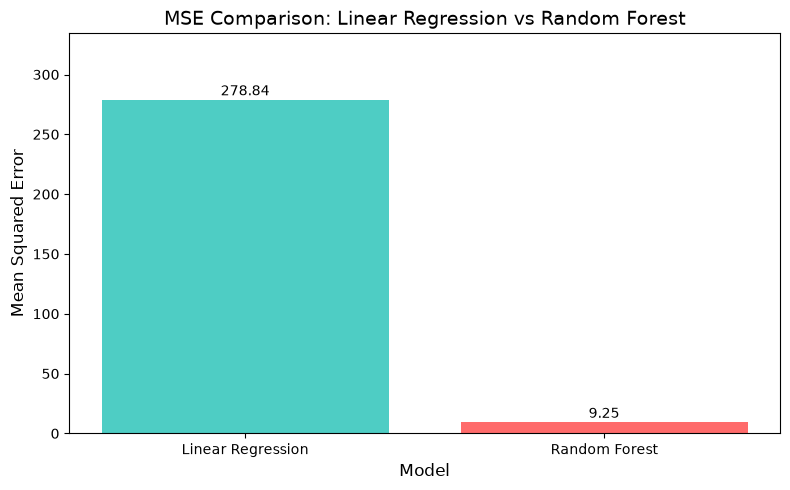

In [13]:
# ============================================================
# CELL 11: MSE COMPARISON CHART
# ============================================================

plt.figure(figsize=(8, 5))
bars = plt.bar(results['Model'], results['MSE'], color=['#4ECDC4', '#FF6B6B'])
plt.title('MSE Comparison: Linear Regression vs Random Forest', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.ylim(0, max(results['MSE']) * 1.2)

for bar, value in zip(bars, results['MSE']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{value:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/assignment3_chart1.png', dpi=150, bbox_inches='tight')
plt.show()

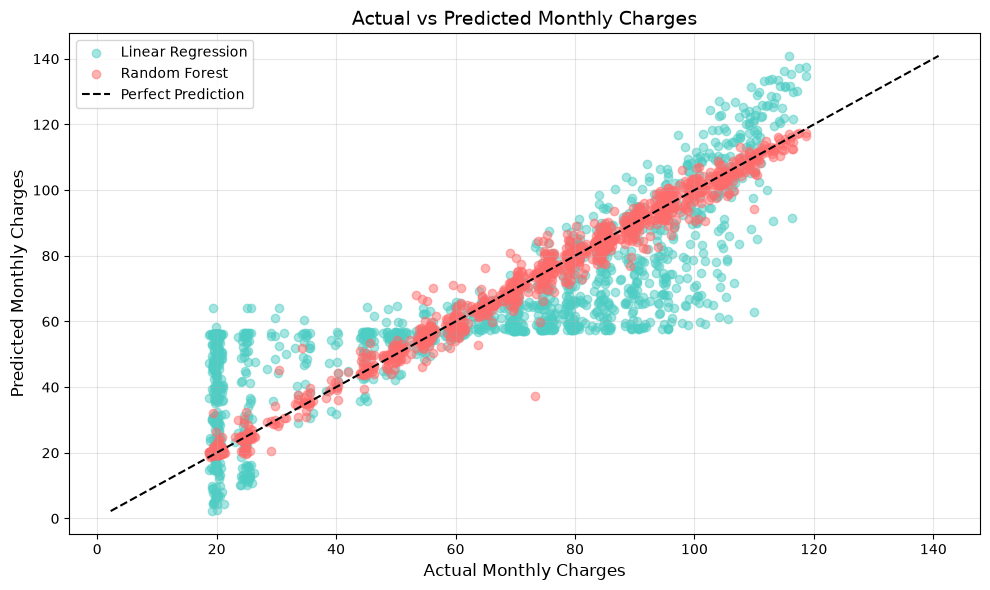

In [14]:
# ============================================================
# CELL 12: ACTUAL VS PREDICTED SCATTER PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_lr, alpha=0.5, label='Linear Regression', color='#4ECDC4')
plt.scatter(y_test, y_pred_rf, alpha=0.5, label='Random Forest', color='#FF6B6B')

min_val = min(y_test.min(), y_pred_lr.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_lr.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Perfect Prediction')

plt.xlabel('Actual Monthly Charges', fontsize=12)
plt.ylabel('Predicted Monthly Charges', fontsize=12)
plt.title('Actual vs Predicted Monthly Charges', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/assignment3_chart2.png', dpi=150, bbox_inches='tight')
plt.show()